<a href="https://colab.research.google.com/github/willbueno/VWCO-Curso-IA/blob/main/3%20-%20Processamento%20de%20Imagem/Roteiro_03_part3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Roteiro Processamento de Imagens**
## Utilizar este Notebook para executar os comandos.
**Arquivo de referência:** *Roteiro Processamento de Imagens.docx*

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
image = cv2.imread('/content/contorno.tif', cv2.IMREAD_GRAYSCALE)

In [3]:
resulting_image = cv2.GaussianBlur(image, ksize=(9, 9), sigmaX=9, sigmaY=9)
(T, imageBin) = cv2.threshold(
                resulting_image,
                0,
                255,
                cv2.THRESH_BINARY+cv2.THRESH_OTSU)

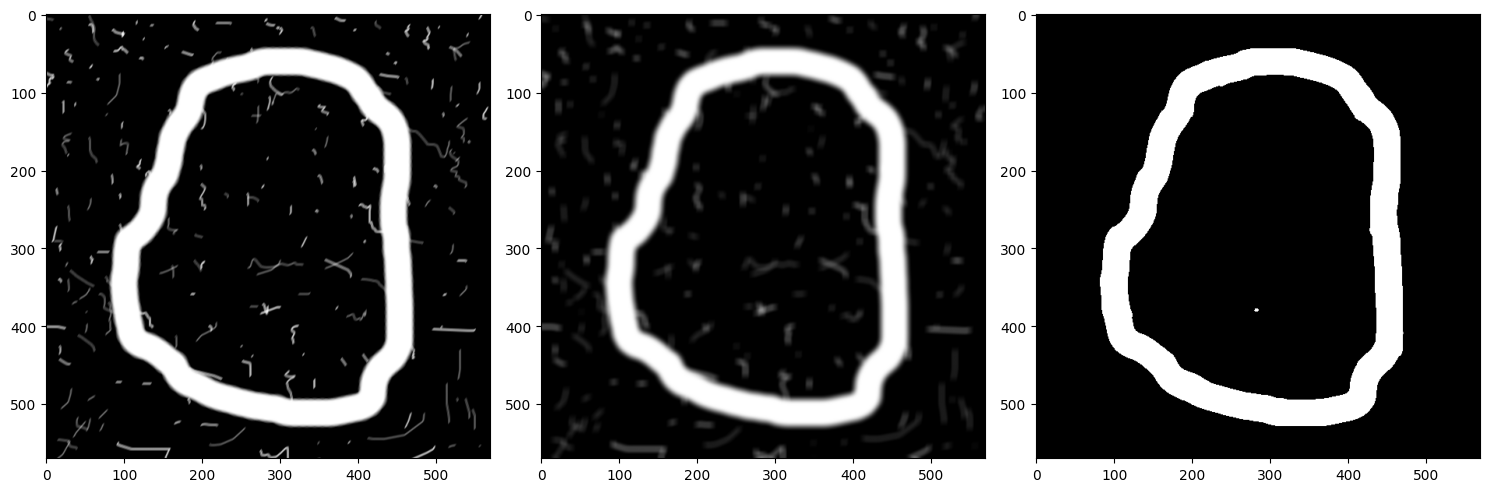

In [4]:
fig, axes = plt.subplots(1,3, figsize=(15,10))
axes[0].imshow(image, cmap='gray')
axes[1].imshow(resulting_image, cmap='gray')
axes[2].imshow(imageBin, cmap='gray')
plt.tight_layout()
plt.show()

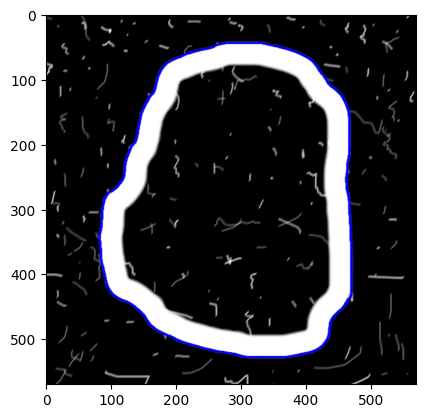

Quantidade de pontos do contorno:  1356
Número de contornos encontrados: 1


In [5]:
contours, hierarchy = cv2.findContours(
                      imageBin,
                      mode=cv2.RETR_EXTERNAL,
                      method=cv2.CHAIN_APPROX_NONE)

image_copy = cv2.cvtColor(image.copy(), cv2.COLOR_GRAY2BGR)
cv2.drawContours(image=image_copy,
                 contours=contours,
                 contourIdx=0,
                 color=(0, 0, 255),
                 thickness=2,
                 lineType=cv2.LINE_AA)

plt.imshow(image_copy)
plt.show()
print('Quantidade de pontos do contorno: ', len(contours[0]))
print(f'Número de contornos encontrados: {len(contours)}')

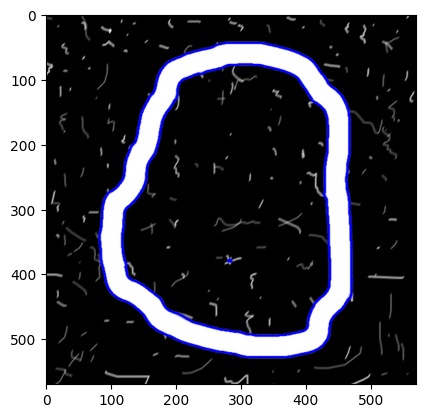

Quantidade de pontos do contorno:  1356
Número de contornos encontrados: 3


In [6]:
contours, hierarchy = cv2.findContours(
                      imageBin,
                      mode=cv2.RETR_LIST,
                      method=cv2.CHAIN_APPROX_NONE)

image_copy = cv2.cvtColor(image.copy(), cv2.COLOR_GRAY2BGR)
cv2.drawContours(image=image_copy,
                 contours=contours,
                 contourIdx=-1,
                 color=(0, 0, 255),
                 thickness=2,
                 lineType=cv2.LINE_AA)

plt.imshow(image_copy)
plt.show()
print('Quantidade de pontos do contorno: ', len(contours[2]))
print(f'Número de contornos encontrados: {len(contours)}')

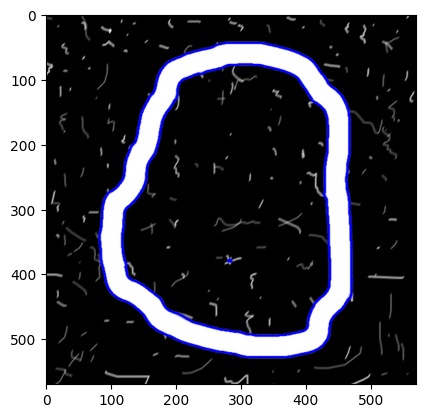

Quantidade de pontos do contorno:  548
Número de contornos encontrados: 3


In [7]:
contours1, hierarchy1 = cv2.findContours(
                        imageBin,
                        mode=cv2.RETR_LIST,
                        method=cv2.CHAIN_APPROX_SIMPLE)

image_copy1 = cv2.cvtColor(image.copy(), cv2.COLOR_GRAY2BGR)
cv2.drawContours(image=image_copy1,
                 contours=contours1,
                 contourIdx=-1,
                 color=(0, 0, 255),
                 thickness=2,
                 lineType=cv2.LINE_AA)

plt.imshow(image_copy)
plt.show()
print('Quantidade de pontos do contorno: ', len(contours1[2]))
print(f'Número de contornos encontrados: {len(contours1)}')

In [8]:
import math

image = cv2.imread('bone.tif', cv2.IMREAD_GRAYSCALE)

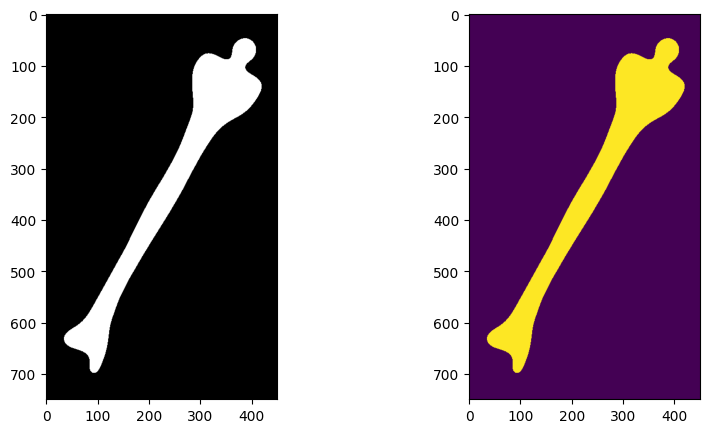

In [9]:
fig, axes = plt.subplots(1,2, figsize=(10,5))
axes[0].imshow(image, cmap='gray')
plt.imshow(image)
plt.show()

In [10]:
contours, hierarchy = cv2.findContours(
                      image,
                      mode=cv2.RETR_TREE,
                      method=cv2.CHAIN_APPROX_SIMPLE)
i = 0
cnt = contours[i]

In [11]:
leftmost = tuple(cnt[cnt[:, :, 0].argmin()][0])
rightmost = tuple(cnt[cnt[:, :, 0].argmax()][0])
topmost = tuple(cnt[cnt[:, :, 1].argmin()][0])
bottommost = tuple(cnt[cnt[:, :, 1].argmax()][0])
print("Coordenada mais a esquerda: ", leftmost[0], 'e', leftmost[1])
print("Coordenada mais a direita: ", rightmost[0], 'e', rightmost[1])
print("Coordenada mais acima: ", topmost[0], 'e', topmost[1])
print("Coordenada mais abaixo: ", bottommost[0], 'e', bottommost[1])

Coordenada mais a esquerda:  35 e 629
Coordenada mais a direita:  419 e 145
Coordenada mais acima:  384 e 47
Coordenada mais abaixo:  90 e 698


In [12]:
diametro = math.sqrt(
           ((bottommost[0] - topmost[0]) ** 2) +
           ((bottommost[1] - topmost[1]) ** 2))
perimetro = cv2.arcLength(cnt, True)
print("Perimetro da Fronteira:", perimetro)
print("Diametro - ponto mais alto - ponto mais baixo:", diametro)

Perimetro da Fronteira: 1729.9494779109955
Diametro - ponto mais alto - ponto mais baixo: 714.3087567711879


In [13]:
x, y, w, h = cv2.boundingRect(cnt)
print("Ponto mais a esquerda, em x:", x)
print("Ponto mais alto, em y:", y)
print("Largura:", w)
print("Altura:", h)

Ponto mais a esquerda, em x: 35
Ponto mais alto, em y: 47
Largura: 385
Altura: 652


In [14]:
cv2.rectangle(image, (x, y), (x+w, y+h), (0, 255, 0), 2)
rect = cv2.minAreaRect(cnt)
box = np.int64(cv2.boxPoints(rect))
image_copy = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)
cv2.drawContours(image_copy, [box], 0, (0, 0, 255), 2)

array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       ...,

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]]], dtype=uint8)

In [15]:
(x1, y1), (MA, ma), angle = cv2.fitEllipse(cnt)
print("x do centro:", x1, "e y do centro:", y1)
print("Largura ou comprimento do eixo menor:", MA)
print("Altura ou comprimento do eixo maior:", ma)
print("Angulo de rotacao (clockwise):", angle)

x do centro: 242.6212921142578 e y do centro: 342.7470703125
Largura ou comprimento do eixo menor: 127.0146255493164
Altura ou comprimento do eixo maior: 675.4052124023438
Angulo de rotacao (clockwise): 26.89984893798828


In [16]:
excentricidade = ma / MA
print("Excentididadae:", excentricidade)

Excentididadae: 5.317538901377163


In [17]:
from skimage.measure import moments_hu, moments_normalized, moments_central

In [18]:
image = cv2.imread('hu6.tif', cv2.IMREAD_GRAYSCALE)

In [19]:
for i in range(1,7):
  a= 'hu'+str(i)+'.tif'
  print(a)
  image = cv2.imread(a, cv2.IMREAD_GRAYSCALE)

  mu = moments_central(image)
  nu = moments_normalized(mu)
  momentos = moments_hu(nu)

  print("Momentos:", momentos)
  print(" ")

hu1.tif
Momentos: [1.36095782e-03 7.47242250e-08 3.88213845e-11 4.22443823e-11
 4.29169993e-22 1.14370270e-14 1.65605287e-21]
 
hu2.tif
Momentos: [1.36095782e-03 7.47242250e-08 3.88213845e-11 4.22443823e-11
 4.29169993e-22 1.14370270e-14 1.65605287e-21]
 
hu3.tif
Momentos: [1.36016316e-03 7.48652943e-08 3.93791563e-11 4.24674134e-11
 4.05162788e-22 1.15263358e-14 1.68874523e-21]
 
hu4.tif
Momentos: [1.36095782e-03 7.47242250e-08 3.88213845e-11 4.22443823e-11
 4.29169993e-22 1.14370270e-14 1.65605287e-21]
 
hu5.tif
Momentos: [ 1.36095782e-03  7.47242250e-08  3.88213845e-11  4.22443823e-11
  4.29169993e-22  1.14370270e-14 -1.65605287e-21]
 
hu6.tif
Momentos: [1.36100327e-03 7.47097622e-08 3.87745092e-11 4.22455369e-11
 4.30247767e-22 1.14355032e-14 1.65477814e-21]
 
